In [1]:
import pandas as pd
from utils.eda_utils import EDAUtils
from utils.prob_utils import ProbUtils
import os
import numpy as np

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
edau = EDAUtils()
pu = ProbUtils()

In [27]:
# Set up paths
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
ENSEMBLE_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "ensemble")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")
POST_PROCESSING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "2030_emissions")
IMG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "img")
DOCS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "docs")

In [5]:
#NOTE: The emission values of this databse are in mtons
ndc_ref = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "ndc_reference.csv"))
ndc_ref.head()

,Country,ISO,Unconditional,Conditional,2020,Unconditional_b20,Conditional_b20
0,Afghanistan,AFG,51.7,45.5,34.309517,0.506871,0.326163
1,Angola,AGO,27.6,-1.4,133.309538,-0.792963,-1.010502
2,Albania,ALB,12.0,12.0,8.351838,0.436810,0.436810
3,Andorra,AND,0.3,0.3,0.509745,-0.411471,-0.411471
4,United Arab Emirates,ARE,185.3,185.3,248.728172,-0.255010,-0.255010


In [6]:
ndc_ref.describe()

,Unconditional,Conditional,2020,Unconditional_b20,Conditional_b20
count,198.000000,198.000000,194.000000,194.000000,194.000000
mean,248.339452,231.900563,255.928277,-0.004181,-0.226764
std,1041.219161,1046.849885,1009.413190,0.885062,0.924408
min,-206.000000,-369.400000,-0.810944,-5.400433,-8.890874
25%,7.400000,5.104750,9.819481,-0.372499,-0.507735
50%,35.150000,30.400000,43.999176,-0.014763,-0.157051
75%,135.650000,96.100000,131.454269,0.279519,0.120591
max,13153.400000,13153.400000,12107.803810,4.149031,2.071955


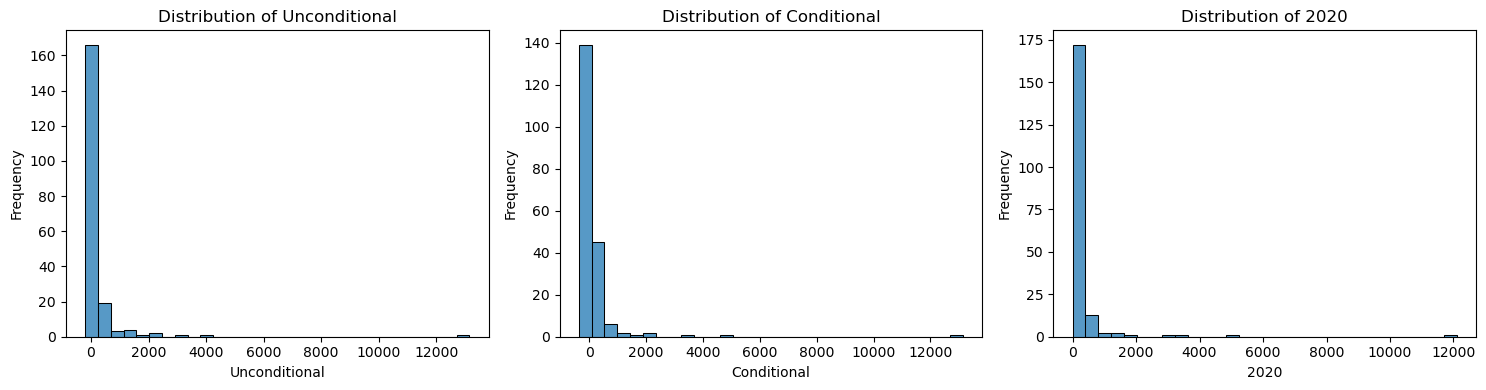

In [7]:
edau.plot_column_distributions(ndc_ref, ["Unconditional", "Conditional", "2020"], kde=False)

In [8]:
ndc_ref["ISO"].unique()

array(['AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS',
       'AZE', 'BDI', 'BEN', 'BFA', 'BGD', 'BHR', 'BHS', 'BIH', 'BLR',
       'BLZ', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN', 'BWA', 'CAF', 'CAN',
       'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COG', 'COK', 'COL',
       'COM', 'CPV', 'CRI', 'CUB', 'DJI', 'DMA', 'DOM', 'DZA', 'ECU',
       'EGY', 'ERI', 'ETH', 'EUU', 'FJI', 'FSM', 'GAB', 'GBR', 'GEO',
       'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRD', 'GTM', 'GUY', 'HND',
       'HTI', 'IDN', 'IND', 'IRN', 'IRQ', 'ISL', 'ISR', 'JAM', 'JOR',
       'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR', 'KNA', 'KOR', 'KWT',
       'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LIE', 'LKA', 'LSO', 'MAR',
       'MCO', 'MDA', 'MDG', 'MDV', 'MEX', 'MHL', 'MKD', 'MLI', 'MMR',
       'MNE', 'MNG', 'MOZ', 'MRT', 'MUS', 'MWI', 'MYS', 'NAM', 'NER',
       'NGA', 'NIC', 'NIU', 'NOR', 'NPL', 'NRU', 'NZL', 'OMN', 'PAK',
       'PAN', 'PER', 'PHL', 'PLW', 'PNG', 'PRK', 'PRY', 'PSE', 'QAT',
       'RUS', 'RWA',

In [9]:
ndc_ref[ndc_ref.Country=="Japan"]

,Country,ISO,Unconditional,Conditional,2020,Unconditional_b20,Conditional_b20
72,Japan,JPN,760.3,760.3,1058.627502,-0.281806,-0.281806


In [10]:
run_id = 1773188058
log_emissions_field_name = "x_log_signed_con_edgar_ghg_mt"


base_df = pd.read_csv(os.path.join(TRAINING_DIR_PATH, f"training_df_{run_id}.csv"))

base_df_filtered = base_df[base_df["year"] == 2020][["iso_alpha_3", log_emissions_field_name]]
base_df_filtered["2020_edgar_ghg_mt"] = np.expm1(base_df_filtered[log_emissions_field_name])
base_df_filtered.head()


,iso_alpha_3,x_log_signed_con_edgar_ghg_mt,2020_edgar_ghg_mt
15,AFG,3.372478,28.150674
33,AGO,4.286101,71.682513
51,ALB,2.181897,7.863104
69,ARG,5.886175,359.025664
87,ARM,2.379782,9.802551


In [11]:
ndc_ref_base = ndc_ref.merge(base_df_filtered, left_on="ISO", right_on="iso_alpha_3", how="right")
ndc_ref_base["unconditional_target"] = (1 + ndc_ref_base["Unconditional_b20"]) * ndc_ref_base["2020_edgar_ghg_mt"]
ndc_ref_base["conditional_target"] = (1 + ndc_ref_base["Conditional_b20"]) * ndc_ref_base["2020_edgar_ghg_mt"]
ndc_ref_base

,Country,ISO,Unconditional,Conditional,2020,Unconditional_b20,Conditional_b20,iso_alpha_3,x_log_signed_con_edgar_ghg_mt,2020_edgar_ghg_mt,unconditional_target,conditional_target
0,Afghanistan,AFG,51.7,45.5,34.309517,0.506871,0.326163,AFG,3.372478,28.150674,42.419422,37.332373
1,Angola,AGO,27.6,-1.4,133.309538,-0.792963,-1.010502,AGO,4.286101,71.682513,14.840929,-0.752801
2,Albania,ALB,12.0,12.0,8.351838,0.436810,0.436810,ALB,2.181897,7.863104,11.297782,11.297782
3,Argentina,ARG,349.0,349.0,390.839275,-0.107050,-0.107050,ARG,5.886175,359.025664,320.592031,320.592031
4,Armenia,ARM,10.6,15.1,10.087433,0.050812,0.496912,ARM,2.379782,9.802551,10.300642,14.673556
...,...,...,...,...,...,...,...,...,...,...,...,...
131,United States of America,USA,3251.2,3251.2,5229.090880,-0.378248,-0.378248,USA,8.633476,5615.567418,3491.492727,3491.492727
132,Uzbekistan,UZB,184.2,353.8,181.190158,0.016612,0.952645,UZB,5.360642,211.861638,215.380980,413.690503
133,South Africa,ZAF,430.7,385.0,552.048280,-0.219815,-0.302597,ZAF,6.314389,551.464312,430.244397,384.592739
134,Zambia,ZMB,72.5,51.0,96.540263,-0.249018,-0.471723,ZMB,3.399656,28.953793,21.743778,15.295623


In [12]:
# ndc_ref_base.to_clipboard(index=False)

In [13]:
ndc_ref_base = ndc_ref_base.dropna()
ndc_ref_base = ndc_ref_base[
    [
        "Country",
        "iso_alpha_3",
        "2020_edgar_ghg_mt",
        "unconditional_target",
        "conditional_target"
    ]
]
ndc_ref_base.head()

,Country,iso_alpha_3,2020_edgar_ghg_mt,unconditional_target,conditional_target
0,Afghanistan,AFG,28.150674,42.419422,37.332373
1,Angola,AGO,71.682513,14.840929,-0.752801
2,Albania,ALB,7.863104,11.297782,11.297782
3,Argentina,ARG,359.025664,320.592031,320.592031
4,Armenia,ARM,9.802551,10.300642,14.673556


In [14]:
ndc_ref_base.to_clipboard(index=False)

In [15]:
projected_df = pd.read_parquet(
    os.path.join(
        POST_PROCESSING_DIR_PATH,
        f"post_processed_projected_emissions_{run_id}.parquet"
    )
)

projected_df.head()

,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,29.511985
2,id_AFG_10,AFG,2024,30.435955
3,id_AFG_10,AFG,2025,31.448054
4,id_AFG_10,AFG,2026,32.404918


In [16]:
target_evaluation_df = pu.ndc_summary(
    projected_df=projected_df,
    ndc_df=ndc_ref_base,
    cap_cols=["unconditional_target", "conditional_target"],
    year=2030
)

target_evaluation_df.head()

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target
0,AFG,949,0.416228,0.321391
1,ALB,991,1.000000,1.000000
2,ARG,998,0.006012,0.006012
3,ARM,992,0.563508,1.000000
4,AUT,992,0.000000,0.000000


In [17]:
target_evaluation_df[target_evaluation_df.iso_alpha_3 == "COL"]

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target


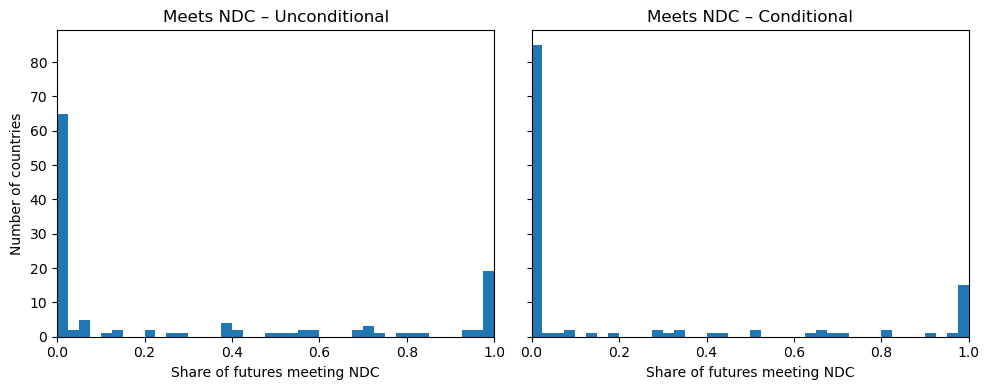

In [18]:
pu.plot_ndc_meets_histograms(
    df=target_evaluation_df,
    bins=40
)

In [19]:
target_evaluation_df.describe()

,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target
count,124.000000,124.000000,124.000000
mean,989.088710,0.303139,0.209752
std,7.045741,0.399414,0.363957
min,949.000000,0.000000,0.000000
25%,987.000000,0.000000,0.000000
50%,991.000000,0.015113,0.000000
75%,993.000000,0.686452,0.304285
max,1000.000000,1.000000,1.000000


In [20]:
country_list_df = ndc_ref_base[["Country", "iso_alpha_3"]].drop_duplicates()
country_list_df

,Country,iso_alpha_3
0,Afghanistan,AFG
1,Angola,AGO
2,Albania,ALB
3,Argentina,ARG
4,Armenia,ARM
...,...,...
131,United States of America,USA
132,Uzbekistan,UZB
133,South Africa,ZAF
134,Zambia,ZMB


In [21]:
projected_df

,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,29.511985
2,id_AFG_10,AFG,2024,30.435955
3,id_AFG_10,AFG,2025,31.448054
4,id_AFG_10,AFG,2026,32.404918
...,...,...,...,...
1103818,id_ZWE_998,ZWE,2026,40.372988
1103819,id_ZWE_998,ZWE,2027,42.264529
1103820,id_ZWE_998,ZWE,2028,44.129562
1103821,id_ZWE_998,ZWE,2029,46.128465


In [22]:
q1_mean_2030_df = pu.compute_2030_q1_mean(
    projected_df
)

q1_mean_2030_df.head()

,iso_alpha_3,2030_q1_mean_value
0,AFG,24.367323
1,ALB,0.599486
2,ARG,364.270168
3,ARM,8.637496
4,AUT,70.130155


In [23]:
ndc_ref_base

,Country,iso_alpha_3,2020_edgar_ghg_mt,unconditional_target,conditional_target
0,Afghanistan,AFG,28.150674,42.419422,37.332373
1,Angola,AGO,71.682513,14.840929,-0.752801
2,Albania,ALB,7.863104,11.297782,11.297782
3,Argentina,ARG,359.025664,320.592031,320.592031
4,Armenia,ARM,9.802551,10.300642,14.673556
...,...,...,...,...,...
131,United States of America,USA,5615.567418,3491.492727,3491.492727
132,Uzbekistan,UZB,211.861638,215.380980,413.690503
133,South Africa,ZAF,551.464312,430.244397,384.592739
134,Zambia,ZMB,28.953793,21.743778,15.295623


In [24]:
target_evaluation_df

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target
0,AFG,949,0.416228,0.321391
1,ALB,991,1.000000,1.000000
2,ARG,998,0.006012,0.006012
3,ARM,992,0.563508,1.000000
4,AUT,992,0.000000,0.000000
...,...,...,...,...
119,URY,988,0.846154,0.653846
120,USA,992,0.000000,0.000000
121,UZB,995,0.003015,1.000000
122,ZMB,992,0.000000,0.000000


In [26]:
prob_analysis_df = target_evaluation_df.merge(ndc_ref_base, how="left", on="iso_alpha_3").merge(q1_mean_2030_df, how="left", on="iso_alpha_3")
prob_analysis_df.head()

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target,Country,2020_edgar_ghg_mt,unconditional_target,conditional_target,2030_q1_mean_value
0,AFG,949,0.416228,0.321391,Afghanistan,28.150674,42.419422,37.332373,24.367323
1,ALB,991,1.000000,1.000000,Albania,7.863104,11.297782,11.297782,0.599486
2,ARG,998,0.006012,0.006012,Argentina,359.025664,320.592031,320.592031,364.270168
3,ARM,992,0.563508,1.000000,Armenia,9.802551,10.300642,14.673556,8.637496
4,AUT,992,0.000000,0.000000,Austria,78.305917,30.071405,30.071405,70.130155


In [28]:
prob_analysis_df.to_csv(os.path.join(DOCS_DIR_PATH, f"ndc_probability_analysis_{run_id}.csv"), index=False)

In [30]:
total_countries = prob_analysis_df['iso_alpha_3'].nunique()
total_countries_with_prob = prob_analysis_df[prob_analysis_df['meets_ndc_unconditional_target'] > 0.5]['iso_alpha_3'].nunique()

print(f"Number of countries in the analysis: {total_countries}")
print(f"Percentage of countries having > 50% probability of meeting the unconditional target: {(total_countries_with_prob / total_countries * 100):.2f}%")

Number of countries in the analysis: 124
Percentage of countries having > 50% probability of meeting the unconditional target: 30.65%


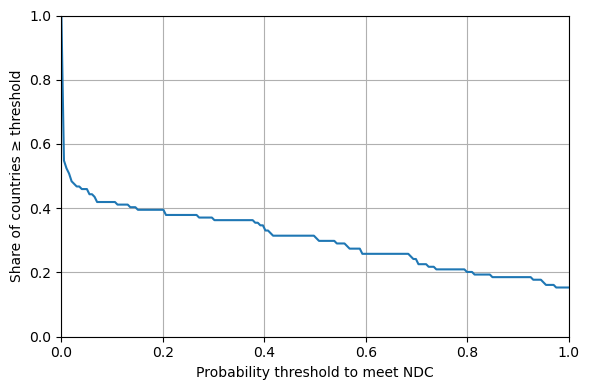

In [31]:
pu.plot_share_countries_above_probability(
    target_evaluation_df,
    prob_col="meets_ndc_unconditional_target"
)